In [1]:
# %% [markdown]
# # 02 — Encoding, Transformación y Balanceo
# ## Proyecto VI · Clasificación · Austin Animal Center
#
# **Objetivo:** Preparar el dataset para el modelado baseline.
# Transformamos variables, aplicamos encoding, dividimos los datos
# y balanceamos la clase minoritaria con SMOTE.
#
# **Input:**  `data/processed/animal_ready_for_modeling.csv`
# **Output:** `data/processed/splits_procesados.npz`
#
# ---
# ### Índice
# 1. Carga del dataset
# 2. Transformación logarítmica — AgeInDays
# 3. Label Encoding del target
# 4. Split estratificado 60/20/20
# 5. Preprocesador — RobustScaler + OHE + OrdinalEncoder
# 6. SMOTE — balanceo de la clase At Risk
# 7. Guardar splits para trabajo en equipo

# %% [markdown]
# ---
# ## 1. Carga del dataset
#
# Cargamos el dataset limpio generado en el preprocesamiento.
# Partimos de `df_pd2` que ya tiene:
# - Breed y Color eliminados
# - Sex limpio (sin nulls)
# - 110.847 filas, 10 columnas

# %%
import numpy as np
import pandas as pd
from sklearn.preprocessing import (RobustScaler, OneHotEncoder,
                                   OrdinalEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

df_pd2 = pd.read_csv("../data/processed/animal_ready_for_modeling.csv")

print(f"Shape: {df_pd2.shape}")
print(f"Columnas: {df_pd2.columns.tolist()}")
print(f"Nulos: {df_pd2.isnull().sum().sum()}")

# %% [markdown]
# ---
# ## Configuración global
#
# Definimos aquí todas las constantes que usarán los notebooks
# de modelado para garantizar consistencia entre compañeros.
#
# | Variable | Contenido |
# |---|---|
# | `FEATURES_NUM` | Features numéricas → RobustScaler |
# | `FEATURES_OHE` | Features nominales → OneHotEncoder |
# | `FEATURES_ORDINAL` | Features ordinales → OrdinalEncoder |
# | `TARGET` | Variable objetivo |
# | `CLASS_ORDER` | Orden fijo de clases para métricas |

# %%
TARGET      = "OutcomeClass"
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

FEATURES_NUM     = ["AgeInDays_log"]
FEATURES_OHE     = ["AnimalType", "Sex", "IntakeType",
                     "IntakeCondition", "breed_type",
                     "Color_grouped", "Season"]
FEATURES_ORDINAL = ["AgeGroup"]

AGE_ORDER = [["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
              "Adulto (3-7a)", "Senior (>7a)"]]

print("Configuración:")
print(f"  Target:           {TARGET}")
print(f"  Features num:     {FEATURES_NUM}")
print(f"  Features OHE:     {FEATURES_OHE}")
print(f"  Features ordinal: {FEATURES_ORDINAL}")

# %% [markdown]
# ---
# ## 2. Transformación logarítmica — AgeInDays
#
# El EDA reveló que AgeInDays tiene un **skewness de 2.158** —
# distribución muy sesgada a la derecha con animales de hasta 8.760 días.
#
# Aplicamos `log1p` (logaritmo de x+1) antes de escalar porque:
# - Comprime los valores extremos acercando media y mediana
# - Beneficia a **LogisticRegression y SVM** que son sensibles a la escala
# - **No afecta** a árboles ni ensemble (invariantes a transformaciones monótonas)
# - `log1p` en lugar de `log` evita problemas con valores = 0

# %%
df_pd2["AgeInDays_log"] = np.log1p(df_pd2["AgeInDays"])

print("Comparativa AgeInDays:")
print(f"  Skewness original: {df_pd2['AgeInDays'].skew():.3f}  ← sesgado")
print(f"  Skewness log1p:    {df_pd2['AgeInDays_log'].skew():.3f}  ← mucho mejor")
print(f"\n  Media original:    {df_pd2['AgeInDays'].mean():.0f} días")
print(f"  Media log1p:       {df_pd2['AgeInDays_log'].mean():.3f}")
print(f"\n  Mediana original:  {df_pd2['AgeInDays'].median():.0f} días")
print(f"  Mediana log1p:     {df_pd2['AgeInDays_log'].median():.3f}")

# %% [markdown]
# ---
# ## 3. Label Encoding del target
#
# Sklearn necesita que el target sea numérico.
# Usamos `LabelEncoder` con un orden fijo (`CLASS_ORDER`) para que
# todos los compañeros tengan la misma codificación.
#
# ⚠️ Guardamos `le_target` — lo necesitaremos para interpretar
# las predicciones del modelo (número → nombre de clase).

# %%
le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y     = df_pd2[TARGET]
y_enc = le_target.transform(y)

print("Target codificado:")
for i, c in enumerate(le_target.classes_):
    n   = (y_enc == i).sum()
    pct = n / len(y_enc) * 100
    print(f"  {i} → {c:<22} ({n:,} registros, {pct:.1f}%)")

# %% [markdown]
# ---
# ## 4. Split estratificado 60/20/20
#
# Dividimos los datos en tres particiones:
#
# | Partición | % | Uso |
# |---|---|---|
# | Train | 60% | Entrenar el modelo |
# | Validación | 20% | Ajustar hiperparámetros |
# | Test | 20% | Evaluación final (solo una vez) |
#
# Usamos `stratify` para preservar la proporción de clases en cada split.
# Sin esto, con At Risk al 3.7% algún fold podría quedar sin ejemplos
# de esa clase y el modelo nunca aprendería a detectarla.
#
# **Por qué 60/20/20 y no 70/15/15:**
# Con 110.847 registros y desbalance severo conviene reservar
# más para validación y test para que las métricas sean fiables.

# %%
X = df_pd2[FEATURES_NUM + FEATURES_OHE + FEATURES_ORDINAL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 × 0.80 = 0.20 → resultado final: 60/20/20

print("División estratificada 60/20/20:")
print(f"  Train:      {X_train.shape[0]:>7,} filas  (60%)")
print(f"  Validación: {X_val.shape[0]:>7,} filas  (20%)")
print(f"  Test:       {X_test.shape[0]:>7,} filas  (20%)")

print("\nProporción At Risk por split (debe ser ~3.7% en todos):")
at_risk_idx = le_target.transform(["At Risk"])[0]
for nombre, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = (y_split == at_risk_idx).mean() * 100
    ok  = "✅" if 3.5 <= pct <= 4.0 else "⚠️"
    print(f"  {ok} At Risk en {nombre}: {pct:.2f}%")

# %% [markdown]
# ---
# ## 5. Preprocesador — RobustScaler + OHE + OrdinalEncoder
#
# Usamos `ColumnTransformer` para aplicar un transformador distinto
# a cada tipo de variable en un solo paso:
#
# | Transformador | Variables | Justificación |
# |---|---|---|
# | `RobustScaler` | AgeInDays_log | Resiste outliers usando mediana en lugar de media |
# | `OneHotEncoder` | 7 nominales | Convierte categorías sin orden a columnas binarias |
# | `OrdinalEncoder` | AgeGroup | Preserva el orden natural Cachorro → Senior |
#
# **Regla crítica:** `fit_transform` solo en train.
# Val y test usan solo `transform` con los parámetros aprendidos del train.
# Si hicieras fit en val/test, estarías dejando que los datos de evaluación
# influyan en la normalización — otra forma de data leakage.

# %%
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler",  RobustScaler(),
                    FEATURES_NUM),
        ("ohe",     OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False),
                    FEATURES_OHE),
        ("ordinal", OrdinalEncoder(categories=AGE_ORDER,
                                   handle_unknown="use_encoded_value",
                                   unknown_value=-1),
                    FEATURES_ORDINAL),
    ],
    remainder="drop"
)

X_train_prep = preprocessor.fit_transform(X_train)   # fit + transform
X_val_prep   = preprocessor.transform(X_val)          # solo transform
X_test_prep  = preprocessor.transform(X_test)         # solo transform

ohe_cols = preprocessor.named_transformers_["ohe"]\
                        .get_feature_names_out(FEATURES_OHE)
all_cols = FEATURES_NUM + list(ohe_cols) + FEATURES_ORDINAL

print("Shape tras preprocesado:")
print(f"  X_train_prep: {X_train_prep.shape}")
print(f"  X_val_prep:   {X_val_prep.shape}")
print(f"  X_test_prep:  {X_test_prep.shape}")
print(f"\nTotal features generadas: {len(all_cols)}")
print(f"  Numéricas:  {len(FEATURES_NUM)}")
print(f"  OHE:        {len(ohe_cols)}  → {list(ohe_cols)}")
print(f"  Ordinales:  {len(FEATURES_ORDINAL)}")

# %% [markdown]
# ---
# ## 6. SMOTE — balanceo de la clase At Risk
#
# Con ratio 13.2:1 (Adoption vs At Risk), los modelos aprenden
# muy bien a identificar adopciones pero casi nunca detectan
# animales en riesgo — exactamente el error más grave posible.
#
# **SMOTE** (Synthetic Minority Oversampling Technique) genera
# ejemplos sintéticos de At Risk interpolando entre ejemplos reales:
# busca los k vecinos más cercanos de cada ejemplo At Risk
# y crea nuevos puntos en el espacio entre ellos.
#
# **Por qué después del preprocesador:**
# SMOTE necesita datos numéricos para interpolar.
# Aplicarlo antes generaría strings sintéticos sin sentido.
#
# **Por qué solo en train:**
# Val y test deben reflejar la distribución real del problema.
# Si los balancearas, evaluarías el modelo en condiciones
# que no existen en producción y las métricas mentirían.

# %%
from imblearn.over_sampling import SMOTE

print("Distribución ANTES de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n   = (y_train == idx).sum()
    pct = n / len(y_train) * 100
    bar = "█" * int(pct / 2)
    print(f"  {clase:<22} {n:>6,}  ({pct:4.1f}%)  {bar}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("\nDistribución DESPUÉS de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n   = (y_train_bal == idx).sum()
    pct = n / len(y_train_bal) * 100
    bar = "█" * int(pct / 2)
    print(f"  {clase:<22} {n:>6,}  ({pct:4.1f}%)  {bar}")

print(f"\nTrain original:   {X_train_prep.shape[0]:>7,} filas")
print(f"Train balanceado: {X_train_bal.shape[0]:>7,} filas")
print(f"Sintéticos gen.:  {X_train_bal.shape[0] - X_train_prep.shape[0]:>7,}")
print(f"\n✅ Val y Test NO se tocan — representan la realidad")
print(f"\nTienes dos versiones de train para comparar en el baseline:")
print(f"  X_train_prep + y_train     → modelos con class_weight='balanced'")
print(f"  X_train_bal  + y_train_bal → modelos con SMOTE")

# %% [markdown]
# ---
# ## 7. Guardar splits para trabajo en equipo
#
# Guardamos todos los arrays en un archivo `.npz` para que
# cualquier compañero pueda cargarlos directamente sin
# repetir todo el pipeline.
#
# **Cómo cargarlos en otro notebook:**
# ```python
# import numpy as np
# data = np.load("../data/processed/splits_procesados.npz")
# X_train_prep = data["X_train_prep"]
# X_train_bal  = data["X_train_bal"]
# X_val_prep   = data["X_val_prep"]
# X_test_prep  = data["X_test_prep"]
# y_train      = data["y_train"]
# y_train_bal  = data["y_train_bal"]
# y_val        = data["y_val"]
# y_test       = data["y_test"]
# ```

# %%
np.savez(
    "../data/processed/splits_procesados.npz",
    X_train_prep = X_train_prep,
    X_train_bal  = X_train_bal,
    X_val_prep   = X_val_prep,
    X_test_prep  = X_test_prep,
    y_train      = y_train,
    y_train_bal  = y_train_bal,
    y_val        = y_val,
    y_test       = y_test
)

print("✅ Splits guardados en data/processed/splits_procesados.npz")
print(f"\nArrays guardados:")
print(f"  X_train_prep:  {X_train_prep.shape}  (train real, para class_weight)")
print(f"  X_train_bal:   {X_train_bal.shape}   (train SMOTE, balanceado)")
print(f"  X_val_prep:    {X_val_prep.shape}    (validación, NO tocar)")
print(f"  X_test_prep:   {X_test_prep.shape}   (test final, NO tocar)")
print(f"\n⚠️  Añadir splits_procesados.npz al .gitignore si pesa más de 100MB")

Shape: (110847, 11)
Columnas: ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'AgeInDays', 'AgeGroup', 'breed_type', 'Color_grouped', 'Season', 'OutcomeClass', 'AgeInDays_log']
Nulos: 0
Configuración:
  Target:           OutcomeClass
  Features num:     ['AgeInDays_log']
  Features OHE:     ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'breed_type', 'Color_grouped', 'Season']
  Features ordinal: ['AgeGroup']
Comparativa AgeInDays:
  Skewness original: 2.160  ← sesgado
  Skewness log1p:    -0.378  ← mucho mejor

  Media original:    793 días
  Media log1p:       5.625

  Mediana original:  365 días
  Mediana log1p:     5.903
Target codificado:
  0 → Adoption               (54,314 registros, 49.0%)
  1 → At Risk                (4,104 registros, 3.7%)
  2 → Return to Owner        (21,157 registros, 19.1%)
  3 → Transfer               (31,272 registros, 28.2%)
División estratificada 60/20/20:
  Train:       66,507 filas  (60%)
  Validación:  22,170 filas  (20%)
  Test:     

Entrenando Random Forest...
¡Entrenamiento completado!

REPORTE DE CLASIFICACIÓN (Datos de Validación)
                 precision    recall  f1-score   support

       Adoption       0.68      0.61      0.64     10863
       Transfer       0.22      0.47      0.30       821
Return to Owner       0.47      0.77      0.59      4232
        At Risk       0.59      0.36      0.45      6254

       accuracy                           0.56     22170
      macro avg       0.49      0.55      0.49     22170
   weighted avg       0.60      0.56      0.56     22170



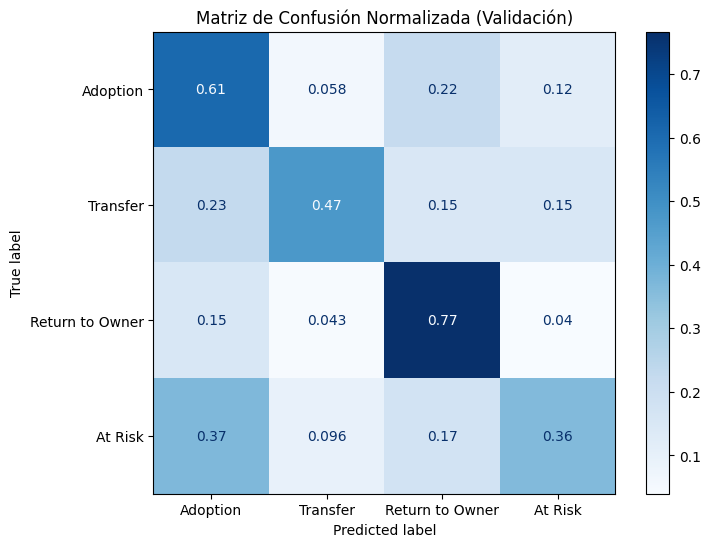

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Cargar los datos procesados
data = np.load("../data/processed/splits_procesados.npz")

# Usamos la versión balanceada con SMOTE para que el modelo "vea" suficientes casos At Risk
X_train = data["X_train_bal"]
y_train = data["y_train_bal"]

# IMPORTANTE: Validación y Test siempre con datos reales (prep), nunca sintéticos
X_val = data["X_val_prep"]
y_val = data["y_val"]

# 2. Configuración del modelo
# Definimos un max_depth para evitar que el modelo se memorice los datos sintéticos de SMOTE
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

# 3. Entrenamiento
print("Entrenando Random Forest...")
rf_baseline.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# 4. Evaluación en Validación
y_pred = rf_baseline.predict(X_val)

# Nombres de las clases para el reporte
target_names = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (Datos de Validación)")
print("="*50)
print(classification_report(y_val, y_pred, target_names=target_names))

# 5. Visualización de la Matriz de Confusión
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, 
    display_labels=target_names, 
    cmap="Blues", 
    ax=ax,
    normalize='true' # Mostramos porcentajes para ver mejor los errores
)
plt.title("Matriz de Confusión Normalizada (Validación)")
plt.show()

¿Qué estamos buscando en estos resultados?
Recall en "At Risk": Esta es tu métrica de oro. Como es la clase más sensible (animales en peligro), queremos que este número sea lo más alto posible.

Overfitting: Si ves que en tu terminal el modelo parece perfecto pero en la matriz de confusión hay muchos errores, es que necesitamos ajustar la profundidad.

Confusión entre Clases: Fíjate si el modelo confunde Transfer con Adoption. Es normal, pero la matriz te dirá qué tan grave es.

In [3]:
# Evaluar en Entrenamiento (con SMOTE)
train_score = rf_baseline.score(X_train, y_train)

# Evaluar en Validación (Real)
val_score = rf_baseline.score(X_val, y_val)

print(f"Precisión en Entrenamiento: {train_score:.4f}")
print(f"Precisión en Validación:    {val_score:.4f}")
print(f"Diferencia (Gap):           {train_score - val_score:.4f}")

Precisión en Entrenamiento: 0.6391
Precisión en Validación:    0.5631
Diferencia (Gap):           0.0759


Si el Gap es > 0.10 (10%): Tienes un problema de Overfitting. El modelo es un "estudiante que memorizó el examen" pero no sabe razonar.

Si el Gap es pequeño (< 0.05): Tu modelo está generalizando bien. ¡Felicidades!

2. Cómo "curar" el Overfitting en tu Bosque
Si descubres que tienes mucho sobreajuste, no necesitas cambiar de modelo, solo tienes que ponerle límites (podarlo). Ajusta estos parámetros en tu RandomForestClassifier:

max_depth (Bájalo): Si tenías 15, prueba con 10 o 12. Cuanto más bajo, menos capacidad tiene el árbol de memorizar detalles inútiles.

min_samples_leaf (Súbelo): Cámbialo a 5, 10 o incluso 50. Esto obliga al modelo a que cada "decisión" se base en un grupo grande de animales, ignorando los casos aislados o ruidos.

max_features (Redúcelo): Usa "sqrt" o un número pequeño. Esto hace que cada árbol vea menos columnas a la vez, aumentando la diversidad del bosque.

3. La trampa del SMOTE
Un error común es evaluar el overfitting usando datos con SMOTE. ¡Nunca hagas eso! El overfitting real se mide siempre contra la realidad (X_val_prep), porque los datos sintéticos son "demasiado perfectos" y engañan al modelo haciéndole creer que es mejor de lo que es.

Regla de oro: Entrena con el balanceado (X_train_bal), pero mide el éxito con el real (X_val_prep).

¿Te gustaría que probemos un análisis de importancia de variables? A veces el overfitting ocurre porque el modelo se obsesiona con una sola variable (como una raza específica) y eso nos ayuda a identificarlo rápido. Sería ejecutar un comando muy sencillo.